# SEGO tutorial

In [1]:
import numpy as np
from matplotlib import pyplot as plt

from smtoptim.benchmarks.registry import get_problem

from smtoptim.optimizer import Optimizer, ObjectiveConfig, ConstraintConfig, OptimizerConfig

from smtoptim.surrogate_models import SmtKRG

from smtoptim.acquisition_strategies import MFSEGO

## Importing a test function

In [2]:
problem = get_problem("Branin1")

## EGO (Unconstrained optimization)

In [3]:

obj_config = ObjectiveConfig(
    problem.objective[-1],
    problem.bounds,
    type="minimize",
    surrogate=SmtKRG,           # set which GP to model the objective
    costs = [1],                # each evaluation cost 1 unit of budget
)

opt_config = OptimizerConfig(
    max_iter = 20,              # stopping criterion
    nt_init = 4,                # number of sample in the initial DoE
    verbose = True,
    scaling = True,             # standardize every QoI
)

# configure the optimizer
optimizer = Optimizer(obj_config, opt_config, MFSEGO)
"""
Note: if a single fidelity level is given to the MFSEGO acquisition strategy, it falls back to the SEGO framework.
"""


'\nNote: if a single fidelity level is given to the MFSEGO acquisition strategy, it falls back to the SEGO framework.\n'

In [4]:
# return the optimization data
opt_data = optimizer.optimize()

| iter= 0/20 | budget=4.000/inf | f_min=1.646e+01 | rscv_min=0.000e+00 |
| iter= 1/20 | budget=5.000/inf | f_min=5.223e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.276 | acq_time=0.314
| iter= 2/20 | budget=6.000/inf | f_min=5.223e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.240 | acq_time=0.186
| iter= 3/20 | budget=7.000/inf | f_min=5.223e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.302 | acq_time=0.311
| iter= 4/20 | budget=8.000/inf | f_min=5.223e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.333 | acq_time=0.303
| iter= 5/20 | budget=9.000/inf | f_min=5.223e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.301 | acq_time=0.294
| iter= 6/20 | budget=10.000/inf | f_min=3.502e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.283 | acq_time=0.310
| iter= 7/20 | budget=11.000/inf | f_min=3.502e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.335 | acq_time=0.276
| iter= 8/20 | budget=12.000/inf | f_min=3.114e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.287 | acq_time=0.317
| iter= 9/20

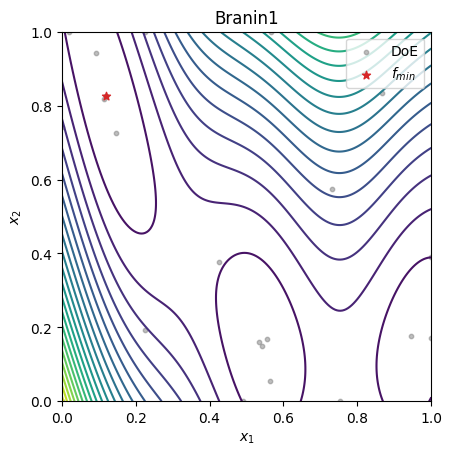

In [5]:
# get the lowest sampled objective value
idx = np.argmin(optimizer.yt[-1])
f_min = optimizer.yt[-1][idx]
x_min = optimizer.xt[-1][idx, :]

X = np.linspace(0, 1, 201)
XX, YY = np.meshgrid(X, X)

data = np.vstack((XX.ravel(), YY.ravel())).T
z = np.empty(data.shape[0])

for i in range(data.shape[0]):
    z[i] = problem.objective[-1](data[i, :])

Z = z.reshape(XX.shape)

fig, ax = plt.subplots()

ax.set_title(problem.name)

ax.contour(XX, YY, Z, levels=20)
ax.scatter(optimizer.xt[-1][:, 0], optimizer.xt[-1][:, 1], 10, color="C7", alpha=0.5, label="DoE")
ax.scatter(x_min[0], x_min[1], c="C3", marker="*", label=r"$f_{min}$", zorder=10)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")

ax.legend()
ax.set_aspect("equal")
plt.show()


## SEGO (Constrained optimization)

In [6]:
obj_config = ObjectiveConfig(
    problem.objective[-1],
    problem.bounds,
    type="minimize",
    surrogate=SmtKRG,
    costs = [1],
)

# configure the constraint
cstr_config = ConstraintConfig(
    problem.constraints[0][-1],
    type="less",                    # set the constraint type (less, greater or equal)
    value=0.0,                      # g(x) <= 0
    surrogate=SmtKRG,               # set which GP to model this constraint
)

opt_config = OptimizerConfig(
    constraints=[cstr_config],      # list the constraints
    max_iter = 20,
    nt_init = 4,
    verbose = True,
    scaling = True,
)

optimizer = Optimizer(obj_config, opt_config, MFSEGO)

opt_data = optimizer.optimize()

| iter= 0/20 | budget=4.000/inf | f_min=1.226e+02 | rscv_min=0.000e+00 |
| iter= 1/20 | budget=5.000/inf | f_min=5.769e+01 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.597 | acq_time=0.669
| iter= 2/20 | budget=6.000/inf | f_min=5.769e+01 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.557 | acq_time=0.219
| iter= 3/20 | budget=7.000/inf | f_min=5.769e+01 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.634 | acq_time=0.292
| iter= 4/20 | budget=8.000/inf | f_min=5.991e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.650 | acq_time=0.300
| iter= 5/20 | budget=9.000/inf | f_min=5.991e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.644 | acq_time=0.364
| iter= 6/20 | budget=10.000/inf | f_min=5.991e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.688 | acq_time=0.336
| iter= 7/20 | budget=11.000/inf | f_min=5.991e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.558 | acq_time=0.913
| iter= 8/20 | budget=12.000/inf | f_min=5.991e+00 | rscv_min=0.000e+00 | lvl=0/0 | gp_time=0.498 | acq_time=1.801
| iter= 9/20

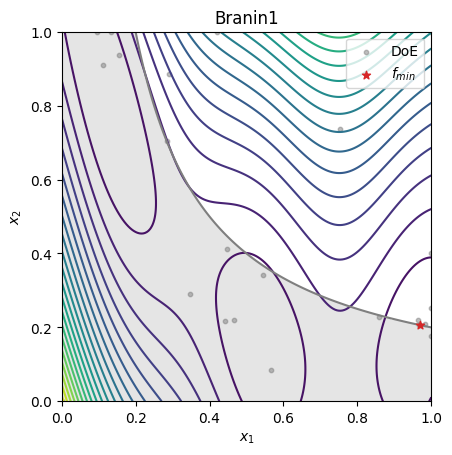

In [7]:
# get the lowest feasible sampled objective value
idx = np.argmin(np.where(optimizer.ct[-1] <= 0, optimizer.yt[-1], np.inf))
f_min = optimizer.yt[-1][idx]
x_min = optimizer.xt[-1][idx, :]

X = np.linspace(0, 1, 201)

XX, YY = np.meshgrid(X, X)

data = np.vstack((XX.ravel(), YY.ravel())).T
z = np.empty(data.shape[0])
c = np.empty(data.shape[0])

for i in range(data.shape[0]):
    z[i] = problem.objective[-1](data[i, :])
    c[i] = problem.constraints[0][-1](data[i, :])

Z = z.reshape(XX.shape)
C = c.reshape(XX.shape)

fig, ax = plt.subplots()

ax.set_title(problem.name)

ax.contour(XX, YY, Z, levels=20)

ax.contourf(XX, YY, np.where(C <= 0, np.nan, C), levels=0, colors="C7", alpha=0.20)
ax.contour(XX, YY, C, levels=[0], colors="C7")

ax.scatter(optimizer.xt[-1][:, 0], optimizer.xt[-1][:, 1], 10, color="C7", alpha=0.5, label="DoE")
ax.scatter(x_min[0], x_min[1], c="C3", marker="*", label=r"$f_{min}$", zorder=10)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")

ax.legend()
ax.set_aspect("equal")
plt.show()